In [30]:
# Import required libraries for data analysis, visualization, and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
#loading trading and sentiment datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [32]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [33]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [34]:
sentiment.shape

(2644, 4)

In [35]:
trades.shape

(211224, 16)

In [36]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [37]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [38]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [39]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [40]:
sentiment.duplicated().sum()

0

In [41]:
trades.duplicated().sum()

0

In [42]:
# Convert sentiment date column to datetime
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [43]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [44]:
# Convert trader timestamps to datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [45]:
#  Extract only the date from timestamp for merging
trades['date'] = trades['Timestamp IST'].dt.date

In [46]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [47]:

# Merge trading data with market sentiment data based on date
merged = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [48]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


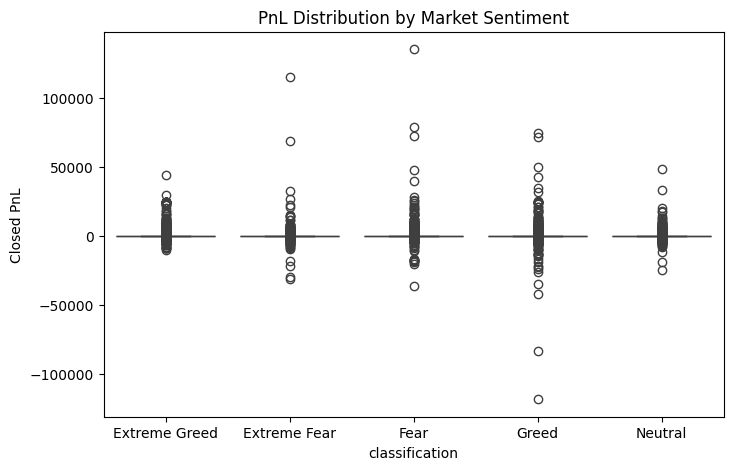

In [49]:
# Visualize the distribution of trader profits/losses across different market sentiment categories

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()

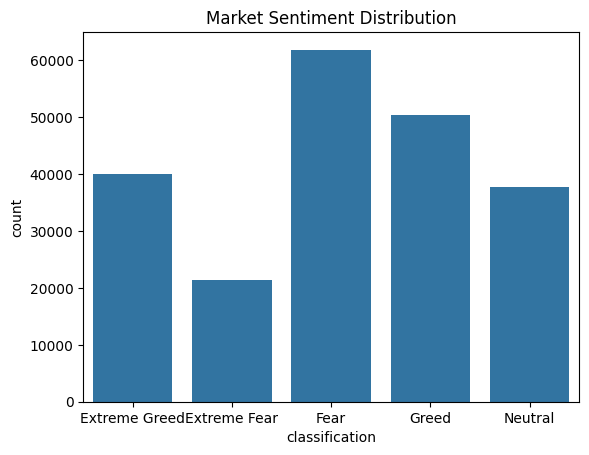

In [50]:

# Count the number of trades that occurred under each market sentiment category
sns.countplot(x='classification', data=merged)
plt.title("Market Sentiment Distribution")
plt.show()

In [51]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [52]:
# Calculate total daily profit/loss for each trader account

daily_pnl = (
    merged.groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index()
)
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [53]:
# Create win/loss label based on trade PnL
merged['win'] = merged['Closed PnL'] > 0

In [54]:
# Calculate win rate per trader

win_rate = (
    merged.groupby('Account')['win']
    .mean()
    .reset_index()
)

win_rate.rename(columns={'win':'win_rate'}, inplace=True)

win_rate.head()


,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [55]:
# Calculate the average trade size (USD) for each trader account

avg_trade_size = (
    merged.groupby('Account')['Size USD']
    .mean()
    .reset_index()
)

avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [56]:
# Calculate number of trades executed each day

trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

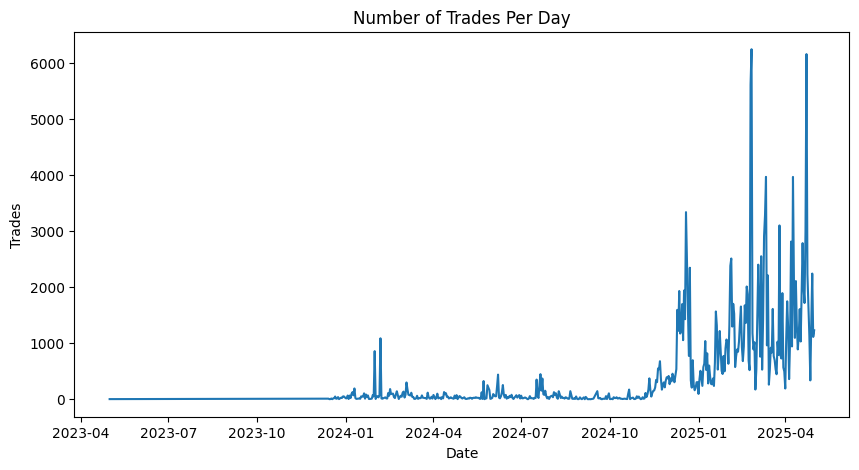

In [60]:


plt.figure(figsize=(10,5))
plt.plot(trades_per_day['date'], trades_per_day['trade_count'])

plt.title("Number of Trades Per Day")
plt.xlabel("Date")
plt.ylabel("Trades")

plt.show()

In [61]:
# Filter only opening positions (long and short)
positions = merged[
    merged['Direction'].isin(['Open Long','Open Short'])
]

# Calculate proportion of long vs short positions
long_short_ratio = positions['Direction'].value_counts(normalize=True)

print(long_short_ratio)

Direction
Open Long     0.55664
Open Short    0.44336
Name: proportion, dtype: float64


In [62]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


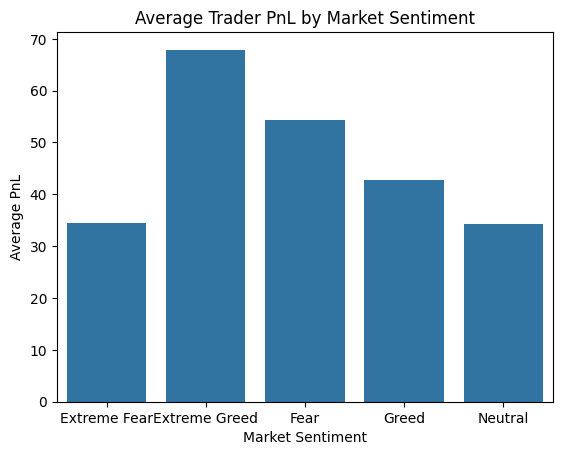

In [63]:
# Plot average trader PnL by market sentiment


sns.barplot(
    x=pnl_by_sentiment.index,
    y=pnl_by_sentiment.values
)

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

In [64]:
# Create a win indicator where profit > 0
merged['win'] = merged['Closed PnL'] > 0

# Calculate win rate for each sentiment category
win_rate_sentiment = (
    merged.groupby('classification')['win']
    .mean()
    .reset_index()
)

print(win_rate_sentiment)

  classification       win
0   Extreme Fear  0.370607
1  Extreme Greed  0.464943
2           Fear  0.420768
3          Greed  0.384828
4        Neutral  0.396991


In [65]:
# Filter only losing trades
losses = merged[merged['Closed PnL'] < 0]

# Calculate average loss for each market sentiment category
drawdown_proxy = (
    losses.groupby('classification')['Closed PnL']
    .mean()
)

print(drawdown_proxy)

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


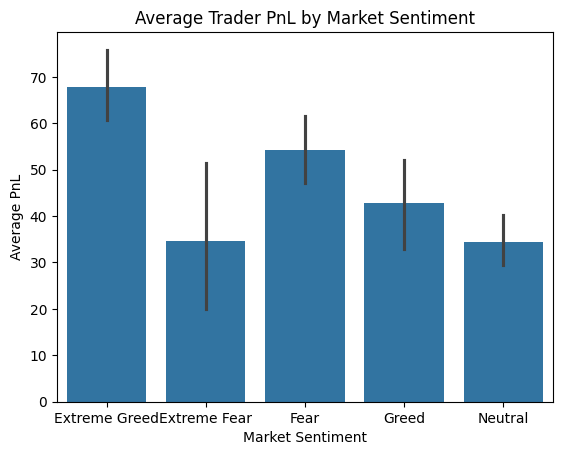

In [66]:
# Plot average trader PnL for each sentiment category


sns.barplot(
    x='classification',
    y='Closed PnL',
    data=merged,
    estimator='mean'
)

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.show()

In [67]:
# Calculate total number of trades under each sentiment category

trades_by_sentiment = merged.groupby('classification').size().reset_index(name='trade_count')
print(trades_by_sentiment)

  classification  trade_count
0   Extreme Fear        21400
1  Extreme Greed        39992
2           Fear        61837
3          Greed        50303
4        Neutral        37686


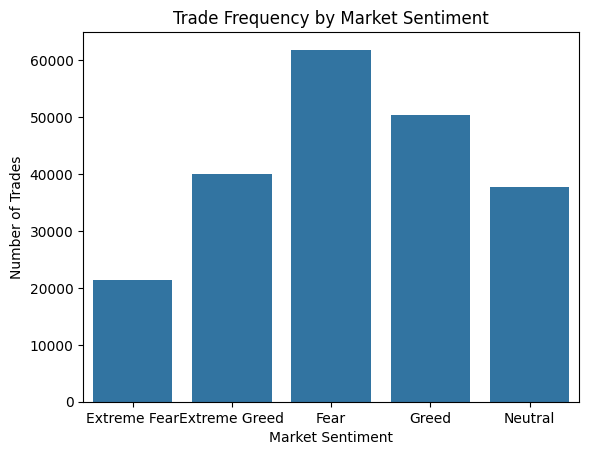

In [68]:
# Visualize trade frequency by sentiment
sns.barplot(data=trades_by_sentiment, x='classification', y='trade_count')

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [69]:
# Calculate average trade size under each sentiment category
position_size_sentiment = (
    merged.groupby('classification')['Size USD']
    .mean()
    .reset_index()
)

print(position_size_sentiment)

  classification     Size USD
0   Extreme Fear  5349.731843
1  Extreme Greed  3112.251565
2           Fear  7816.109931
3          Greed  5736.884375
4        Neutral  4782.732661


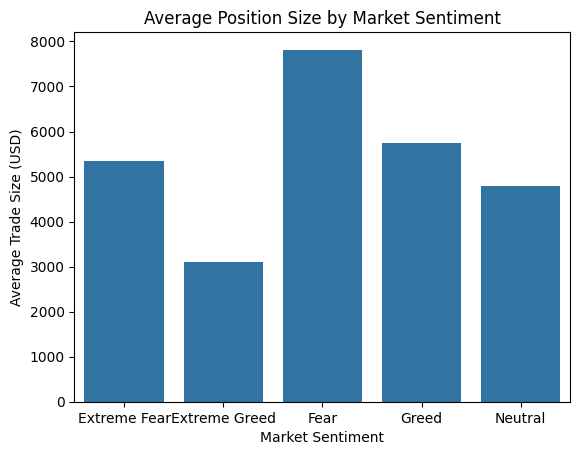

In [70]:
sns.barplot(data=position_size_sentiment, x='classification', y='Size USD')

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [71]:
# Filter only opening long and short positions

positions = merged[merged['Direction'].isin(['Open Long','Open Short'])]
# Count long and short positions for each sentiment category

long_short_by_sentiment = (
    positions.groupby(['classification','Direction'])
    .size()
    .unstack()
)

print(long_short_by_sentiment)

Direction       Open Long  Open Short
classification                       
Extreme Fear         7005        3174
Extreme Greed        6300        7663
Fear                17824       10887
Greed                8544       11664
Neutral             10222        6353


In [72]:
# Calculate long/short ratio for each sentiment category

long_short_ratio = long_short_by_sentiment.div(long_short_by_sentiment.sum(axis=1), axis=0)

print(long_short_ratio)

Direction       Open Long  Open Short
classification                       
Extreme Fear     0.688182    0.311818
Extreme Greed    0.451192    0.548808
Fear             0.620807    0.379193
Greed            0.422803    0.577197
Neutral          0.616712    0.383288


In [73]:
# Calculate number of trades executed by each trader

trader_activity = (
    merged.groupby('Account')
    .size()
    .reset_index(name='trade_count')
)

trader_activity.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [74]:
# Determine median trade count to classify traders

threshold = trader_activity['trade_count'].median()
# Label traders as frequent or infrequent based on activity

trader_activity['trader_type'] = trader_activity['trade_count'].apply(
    lambda x: 'Frequent Trader' if x > threshold else 'Infrequent Trader'
)

trader_activity.head()

,Account,trade_count,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [75]:
# Merge trader activity data with PnL information

activity_analysis = trader_activity.merge(
    merged[['Account','Closed PnL']],
    on='Account'
)
# Compare average PnL for frequent vs infrequent traders

activity_result = activity_analysis.groupby('trader_type')['Closed PnL'].mean()

print(activity_result)

trader_type
Frequent Trader      42.493421
Infrequent Trader    96.943024
Name: Closed PnL, dtype: float64


In [76]:
# Classify traders based on win rate performance

trader_performance = win_rate.copy()
trader_performance['performance_type'] = trader_performance['win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= 0.5 else 'Inconsistent Trader'
)

trader_performance.head()

,Account,win_rate,performance_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Inconsistent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Inconsistent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Inconsistent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Inconsistent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Consistent Winner


In [77]:
# Merge trader performance classification with trade PnL

performance_analysis = trader_performance.merge(
    merged[['Account','Closed PnL']],
    on='Account'
)
# Compare profit distribution between trader performance groups

performance_result = performance_analysis.groupby('performance_type')['Closed PnL'].mean()

print(performance_result)

performance_type
Consistent Winner      45.804111
Inconsistent Trader    48.950849
Name: Closed PnL, dtype: float64


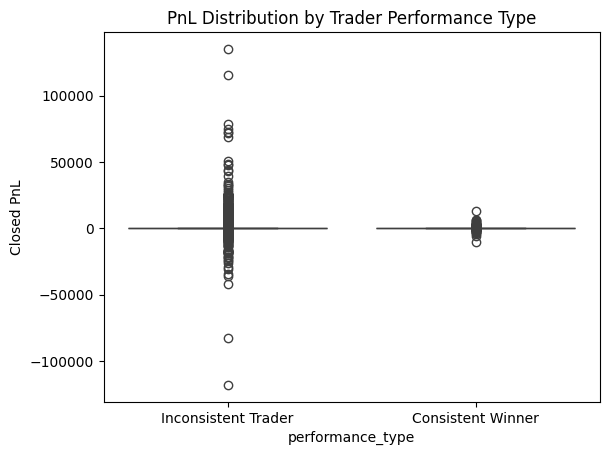

In [78]:
# Visualize profit distribution for consistent vs inconsistent traders


sns.boxplot(
    x='performance_type',
    y='Closed PnL',
    data=performance_analysis
)

plt.title("PnL Distribution by Trader Performance Type")
plt.show()

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
# Create binary label indicating whether a trade was profitable

merged['profit_label'] = (merged['Closed PnL'] > 0).astype(int)
# Select features and target variable
features = merged[['Size USD']]
target = merged['profit_label']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

# Train Random Forest classifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Generate predictions on test data
predictions = model.predict(X_test)

# Evaluate model performance
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.65      0.68      0.66     25039
           1       0.50      0.47      0.49     17206

    accuracy                           0.59     42245
   macro avg       0.58      0.58      0.58     42245
weighted avg       0.59      0.59      0.59     42245

